---
$$ \Large\color{#1a73e8}{\textbf{SwiftFlow App Market Positioning }} $$  $$\large\textbf{Phase 2: Exploratory Data Analysis}$$

---
**Project Metadata:**

*   **Dataset:** Google Play Store Apps (Kaggle)
*   **Author:** Sasi Kiran
*   **Date:** May 2026
*   **Tech Stack:** Python (Pandas, Matplotlib, Seaborn)
---

**Objective:** To identify optimal market positioning strategies for the SwiftFlow productivity app by analyzing Google Play Store data across app size, user ratings, and monetization models.

## Executive Summary

This analysis examines Google Play Store data to identify optimal market positioning for SwiftFlow's Version 1.0 launch across three dimensions: app size, user satisfaction, and monetization.

On app size, the data strongly favors a lightweight build under 10 MB. This is where independent productivity apps achieve peak install volumes, while the 20–50 MB mid-range acts as a market dead zone with significantly lower adoption.

On quality, productivity users set a high bar — the category median sits at 4.2 stars. Critically, the 0–10 MB space is volatile and flooded with low-rated clones, making rigorous QA non-negotiable for Version 1.0.

On monetization, free apps account for over 99.85% of installs in the productivity category. A paid launch would effectively eliminate user adoption. SwiftFlow must launch free and monetize through a freemium model once a user base is established.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/clean_playstore.csv')
df.head()

,App,Category,Rating,Reviews,Size_MB,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Primary_Genre
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,Art & Design
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,Art & Design
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,Art & Design
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,Art & Design
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,Art & Design


### 1. App Size vs. Installs
**Hypothesis:** Smaller apps achieve higher install volumes due to reduced download friction.

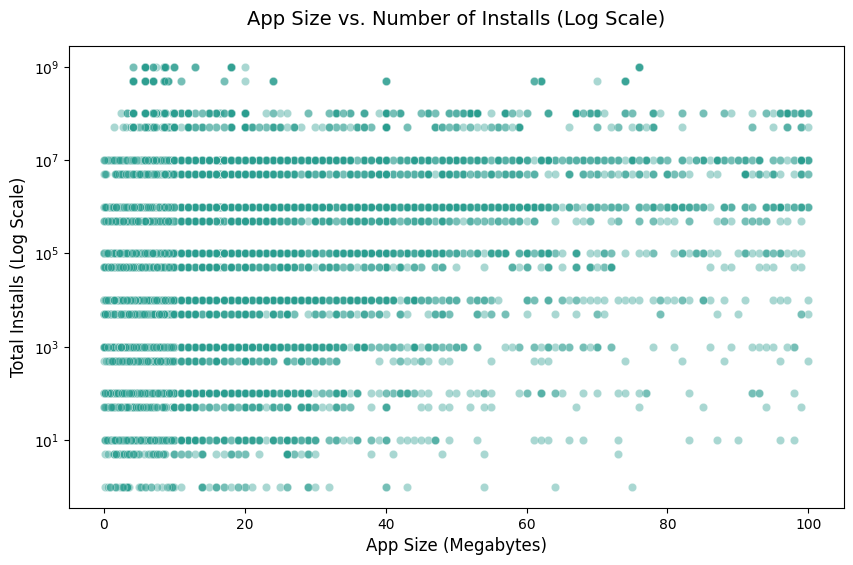

In [2]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data = df,
    x = 'Size_MB',
    y = 'Installs',
    alpha = 0.4,
    color = '#2A9D8F'
)

plt.yscale('log')

plt.title('App Size vs. Number of Installs (Log Scale)', fontsize = 14, pad = 15)
plt.xlabel('App Size (Megabytes)', fontsize=12)
plt.ylabel('Total Installs (Log Scale)', fontsize =12)

plt.show()

### Observation: App Size vs. Installs

**1. The 40MB Threshold:** The vast majority of the market, including the highest-performing viral apps (100M+ installs), is heavily clustered below the 40MB mark, confirming that smaller apps attract significantly higher install volumes.

**2. The Drop-off:** Moderate success continues into the 40–60 MB range, but user adoption declines sharply as app sizes approach 100MB, suggesting users actively avoid heavy downloads.

**3. The Milestone Banding:** The horizontal stripes in the scatter plot reflect Google Play's tiered install reporting (e.g., 1M+, 5M+) rather than exact counts — a data limitation to keep in mind when interpreting install figures throughout this analysis.

> **Note:** While the general trend is clear, a scatter plot of 10,000+ data points is too ambiguous to set a precise engineering size limit for SwiftFlow. The next step applies a binning strategy to calculate exact median installs per size tier.

/tmp/ipykernel_4106/3688038146.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_stats = df.groupby('Size_Bucket')['Installs'].median().reset_index()
/tmp/ipykernel_4106/3688038146.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


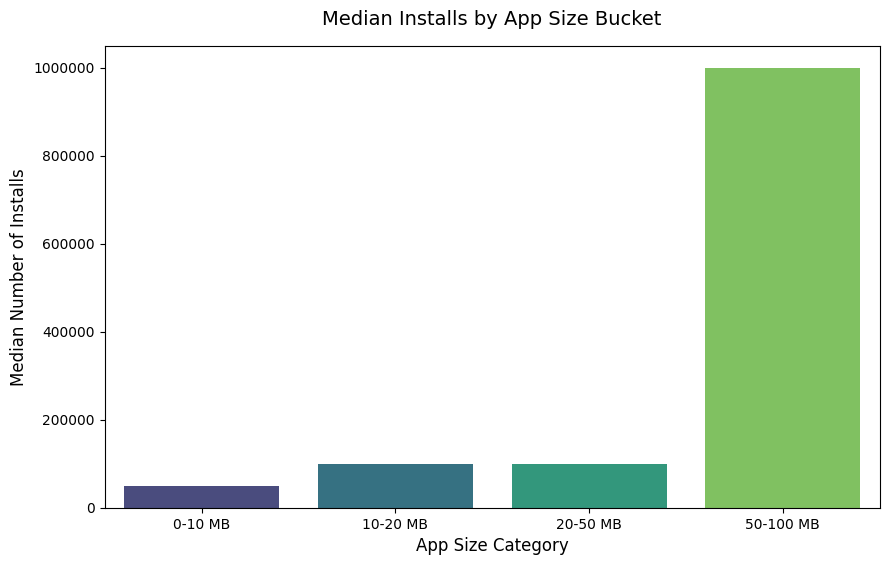

In [3]:
# Define the edges of our buckets (in Megabytes)
size_bins = [0,10,20,50,100]

# Give each bucket a readable label
size_labels = ['0-10 MB', '10-20 MB', '20-50 MB', '50-100 MB']

# Sort every app into its correct bucket, Use pd.cut()
df['Size_Bucket'] = pd.cut(df['Size_MB'], bins=size_bins, labels=size_labels)

# Calculate the median installs for each bucket
bucket_stats = df.groupby('Size_Bucket')['Installs'].median().reset_index()


# Plot Bar Chart
# 5. Visualize the strategy with a Bar Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data = bucket_stats,
    x = 'Size_Bucket',
    y = 'Installs',
    palette='viridis'
)

plt.title('Median Installs by App Size Bucket', fontsize=14, pad=15)
plt.xlabel('App Size Category', fontsize=12)
plt.ylabel('Median Number of Installs', fontsize=12)

# Format the Y-axis to show real numbers
plt.ticklabel_format(style='plain', axis='y')

plt.show()


### Observation: Global Market Size vs. Installs

**1. The Heavyweight Spike:** Apps in the 50–100 MB bucket reach a median of 1,000,000 installs — a 10x jump compared to mid-tier buckets, which appears to contradict our lightweight hypothesis at first glance.

**2. The Mid-Market Plateau:** Apps in the 10–50 MB range show nearly identical adoption rates, stabilizing around 100,000 median installs. Within this band, minor size reductions offer no meaningful download advantage.

**3. The Data Limitation:** This global view is heavily skewed by AAA mobile games, which naturally occupy the 50–100 MB tier and carry massive marketing budgets behind them. Global median installs cannot be used to set engineering constraints for a utility application like SwiftFlow.

> **Note:** The global data is misleading for our use case. The next step isolates the Productivity category to eliminate the game skew and derive a size benchmark that is actually relevant to SwiftFlow.

### 2. Category-Specific Size Ceiling (Productivity)
**Hypothesis:** Isolating the Productivity category will reveal a more accurate size-to-install relationship, free from the skew introduced by AAA mobile games.

/tmp/ipykernel_4106/1422964688.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prod_stats = swiftflow_market.groupby('Size_Buckets')['Installs'].median().reset_index()
/tmp/ipykernel_4106/1422964688.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


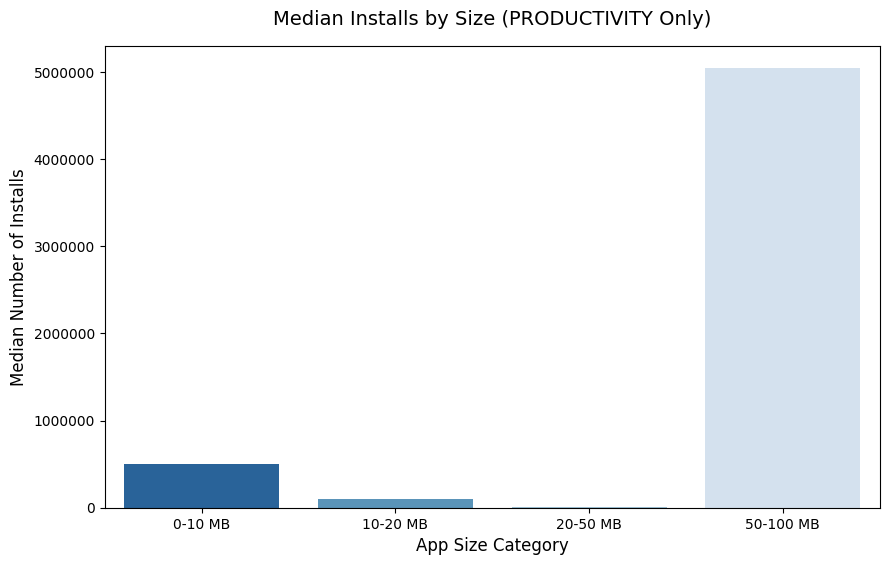

In [4]:
swiftflow_market = df[df['Category']=='PRODUCTIVITY'].copy()

size_bins = [0, 10, 20, 50, 100]

size_labels = ['0-10 MB', '10-20 MB', '20-50 MB', '50-100 MB']

swiftflow_market['Size_Buckets'] = pd.cut(swiftflow_market['Size_MB'], bins= size_bins, labels = size_labels)

prod_stats = swiftflow_market.groupby('Size_Buckets')['Installs'].median().reset_index()

# Visualize the isolated market
plt.figure(figsize=(10, 6))
sns.barplot(
    data = prod_stats,
    x = 'Size_Buckets',
    y = 'Installs',
    palette = 'Blues_r'
)

plt.title('Median Installs by Size (PRODUCTIVITY Only)', fontsize=14, pad=15)
plt.xlabel('App Size Category', fontsize=12)
plt.ylabel('Median Number of Installs', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

### Observation: The Productivity "Dead Zone"

**1. The Lightweight Advantage:** Within the Productivity category, apps under 10 MB achieve a median of 500,000 installs — confirming that ultra-lightweight tools have a strong, established market among productivity users.

**2. The Mid-Market Dead Zone:** Adoption collapses sharply in the 10–50 MB range, with median installs dropping significantly. Within this band, size increases yield no adoption benefit — users simply skip over mid-sized productivity apps.

**3. The Enterprise Anomaly:** The 50–100 MB bucket spikes to 5,000,000 median installs, but this is not an opportunity — it is the footprint of enterprise giants like Microsoft Office and Google Workspace, whose brand authority allows users to tolerate large file sizes. This tier is not accessible to a new market entrant.

> **Note:** SwiftFlow faces a clear binary choice — stay under 10 MB to compete with independent productivity tools, or cross 50 MB to compete with Microsoft and Google. The 10–50 MB range is a dead zone that should be avoided entirely. For a Version 1.0 launch, the 0–10 MB strategy is the only viable path.

### 3. User Satisfaction: Rating Distributions by Market Segment
**Hypothesis:** Productivity users maintain higher rating standards compared to other app categories, setting a more demanding QA benchmark for SwiftFlow's Version 1.0 launch.

/tmp/ipykernel_4106/3824459809.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


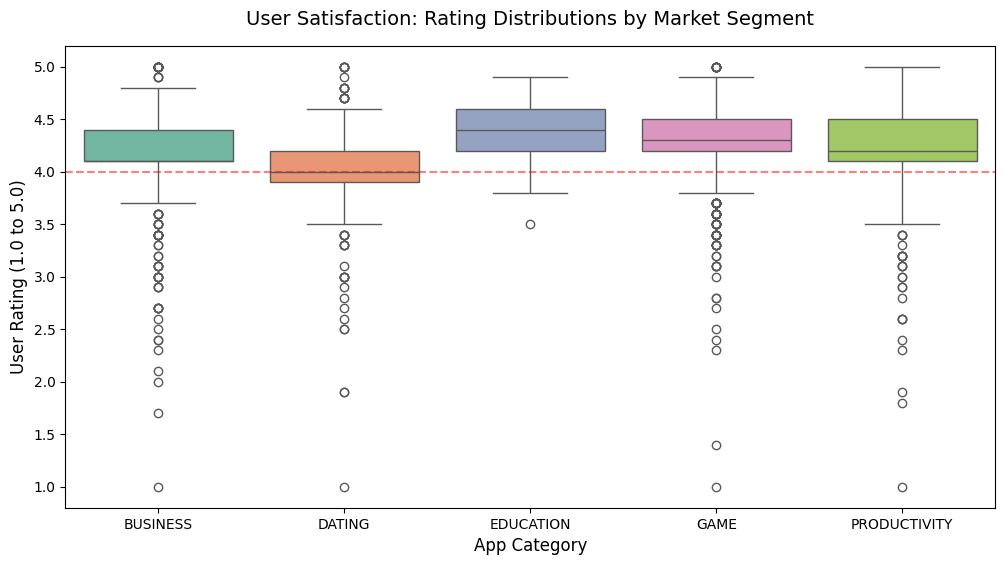

In [5]:
# Define specific market segments we want to compare
target_categories = ['PRODUCTIVITY', 'BUSINESS', 'GAME', 'DATING', 'EDUCATION']

market_comparision = df[df['Category'].isin(target_categories)]

plt.figure(figsize=(12,6))
sns.boxplot(
    data = market_comparision,
    x = 'Category',
    y = 'Rating',
    palette = 'Set2'
)

plt.title('User Satisfaction: Rating Distributions by Market Segment', fontsize=14, pad=15)
plt.xlabel('App Category', fontsize=12)
plt.ylabel('User Rating (1.0 to 5.0)', fontsize=12)

# horizontal line at 4.0 to act as a "Success Benchmark"
plt.axhline(y=4.0, color='red', linestyle='--', alpha=0.5)

plt.show()

### Observation: Market Segment Rating Distributions

**1. The Market Baseline:** Across all major categories analyzed, the median user rating sits comfortably above the 4.0 threshold. The `PRODUCTIVITY` category specifically holds a median of approximately 4.2, indicating a satisfied but highly expectant user base that judges apps strictly on utility.

**2. The Dating Anomaly:** The `DATING` category is the only segment falling below the 4.0 threshold, reflecting that user satisfaction is heavily shaped by the nature of the app itself. Unlike productivity users, dating app users factor in external emotional outcomes — making it an unreliable benchmark for SwiftFlow.

**3. The QA Benchmark:** A 4.2 median rating sets the minimum acceptable quality bar for SwiftFlow's Version 1.0 launch. Shipping below this threshold in the Productivity category would place SwiftFlow in the bottom tier of user satisfaction for its own market.

> **Note:** The global category view establishes the rating benchmark, but does not reveal whether app size influences user satisfaction within Productivity specifically. The next step isolates the Productivity category to test whether lightweight apps are rated differently from heavier ones.

### 3.1 The Impact of App Size on Ratings
**Hypothesis:** Heavier productivity apps receive lower user satisfaction scores due to increased complexity, slower performance, and higher user expectations relative to lightweight alternatives.

/tmp/ipykernel_4106/3228916459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


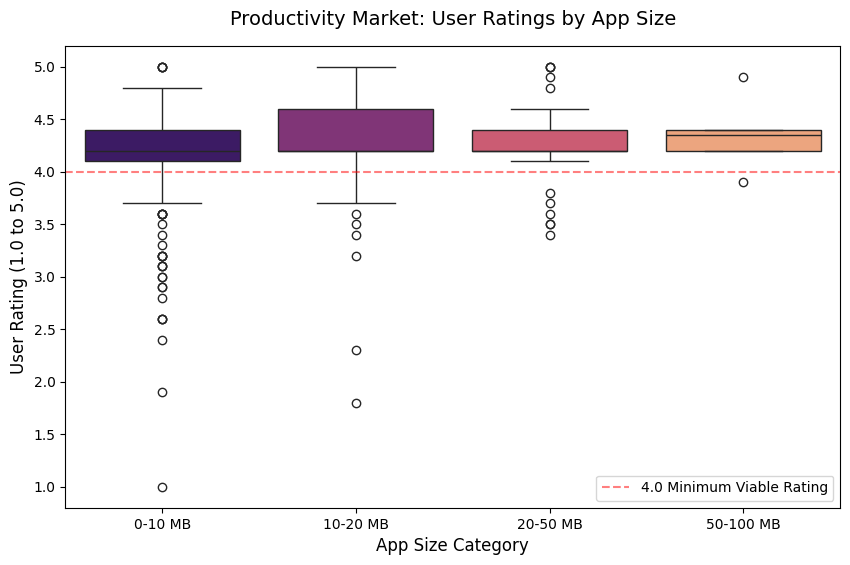

In [6]:
plt.figure(figsize=(10, 6))

# Build the Box Plot using our isolated Productivity market and Size Buckets
sns.boxplot(
    data=swiftflow_market,
    x='Size_Bucket',
    y='Rating',
    palette='magma'
)

plt.title('Productivity Market: User Ratings by App Size', fontsize=14, pad=15)
plt.xlabel('App Size Category', fontsize=12)
plt.ylabel('User Rating (1.0 to 5.0)', fontsize=12)
plt.axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='4.0 Minimum Viable Rating')
plt.legend()

plt.show()

### Observation: Size vs. Satisfaction (The Quality Paradox)

**1. Hypothesis Rejected:** Contrary to our initial hypothesis, app size does not negatively impact user ratings. Across all size buckets in the Productivity category, the median rating remains stable between 4.2 and 4.4 — consistently above the 4.0 minimum viable threshold regardless of size.

**2. The Variance Problem:** The more significant insight lies in rating volatility, not the median. The 0–10 MB bucket shows the highest variance, with ratings crashing as low as 1.0 at the lower end. The 50–100 MB bucket, by contrast, is tightly controlled with almost no apps falling below 3.9 — reflecting the polished output of enterprise-grade QA teams.

**3. The Indie vs. Enterprise Divide:** The 0–10 MB space has no barrier to entry, making it accessible to indie developers but also flooded with low-quality clones that drag the lower end of ratings down. The 50–100 MB space is effectively gated by enterprise giants like Microsoft and Google, whose dedicated QA processes ensure consistent quality at scale.

> **Note:** SwiftFlow is confirmed to target the 0–10 MB bucket for downloads, but this chart introduces a critical engineering constraint — the lightweight space punishes buggy releases severely. Version 1.0 must prioritize QA testing to avoid the low-rating trap that buries most indie productivity apps.

### 4. Monetization Strategy: Free vs. Paid Adoption
**Hypothesis:** Free productivity apps achieve significantly higher install volumes than paid alternatives, making an upfront pricing model an ineffective strategy for a new market entrant.

/tmp/ipykernel_4106/3469158900.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


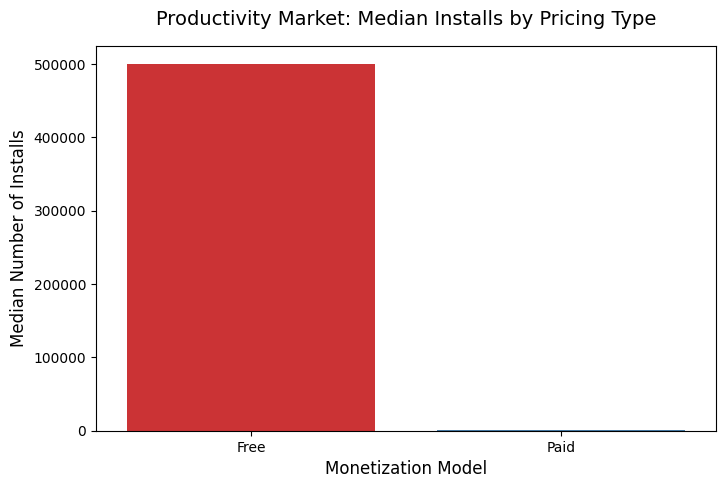

   Type  Installs
0  Free  500000.0
1  Paid     750.0


In [9]:
# Calculate the median installs for Free vs. Paid productivity apps
pricing_stats = swiftflow_market.groupby('Type')['Installs'].median().reset_index()

# Visualize the massive divide
plt.figure(figsize=(8, 5))
sns.barplot(
    data=pricing_stats,
    x='Type',
    y='Installs',
    palette='Set1' # Distinct red/blue contrast
)

# Professional formatting
plt.title('Productivity Market: Median Installs by Pricing Type', fontsize=14, pad=15)
plt.xlabel('Monetization Model', fontsize=12)
plt.ylabel('Median Number of Installs', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')

plt.show()

print(pricing_stats)

In [8]:
total = pricing_stats['Installs'].sum()
print(pricing_stats.assign(share=lambda x: x['Installs']/total*100))

   Type  Installs      share
0  Free  500000.0  99.850225
1  Paid     750.0   0.149775


### Observation: The Paywall Penalty

**1. Free Dominates Entirely:** Within the Productivity category, free apps completely dominate user adoption. Free apps account for over **99.85% of total median installs**, making the performance gap between Free and Paid models effectively insurmountable for a new market entrant.

**2. The Paywall Effect:** Launching with an upfront price does not simply reduce downloads — it virtually eliminates them. Paid productivity apps are passed over by users who have an abundance of free, high-quality alternatives available. Users are not willing to pay before experiencing the product's value.

**3. The Freemium Imperative:** This data makes the monetization decision unambiguous. SwiftFlow must launch as a **100% Free application** to secure market placement and build an initial user base. Once a loyal user base is established, a **Freemium model** (offering premium features at a subscription tier) is the only viable path to monetization without sacrificing adoption.

> **Note:** Hypothesis confirmed. The monetization strategy for SwiftFlow Version 1.0 is unambiguous — launch free, monetize later through a freemium tier once user trust and retention are established.